c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 60 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', Erf

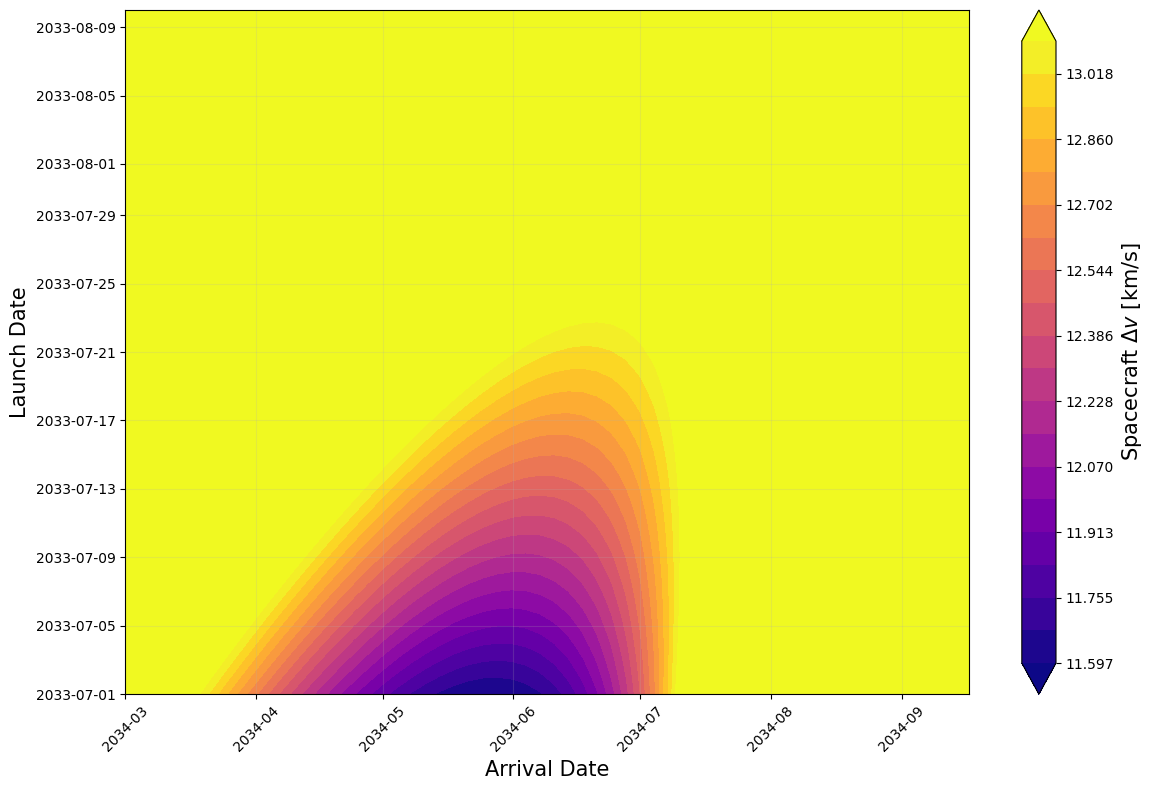


--- OPTIMIZED L5 MISSION OPPORTUNITY ---
Optimal Launch:  2033-07-01
Optimal Arrival: 2034-05-28
LV TMI Burn:     12.74 km/s
S/C Capture Δv:  11596.7 m/s
Operational Date: Jan 1, 2036 (Deadline Met: Yes)


c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.time import Time
from poliastro.bodies import Earth, Mars, Sun
from poliastro.twobody import Orbit
from poliastro.iod import lambert
from poliastro.util import norm
import warnings
from astropy.utils.exceptions import AstropyWarning

warnings.simplefilter('ignore', category=AstropyWarning)

def get_l5_state(arrival_date):

    mars_orbit = Orbit.from_body_ephem(Mars, arrival_date)
    r_m, v_m = mars_orbit.rv()
    theta = -60 * u.deg
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s, 0), (s, c, 0), (0, 0, 1)))
    return (R @ r_m.value) * r_m.unit, (R @ v_m.value) * v_m.unit


launch_dates = Time("2033-07-01") + np.linspace(0, 40, 60) * u.day 
arrival_dates = Time("2034-03-01") + np.linspace(0, 200, 60) * u.day 

sc_dv_matrix = np.zeros((len(launch_dates), len(arrival_dates)))
lv_dv_matrix = np.zeros((len(launch_dates), len(arrival_dates)))



for i, ld in enumerate(launch_dates):
    for j, ad in enumerate(arrival_dates):
        tof = ad - ld
        if tof.value <= 180 or tof.value >= 450:
            sc_dv_matrix[i, j] = np.nan
            continue
        try:
            r_earth, v_earth = Orbit.from_body_ephem(Earth, ld).rv()
            r_l5, v_l5 = get_l5_state(ad)
            (v_dep, v_arr), = lambert(Sun.k, r_earth, r_l5, tof)
            
            
            lv_dv_matrix[i, j] = norm(v_dep - v_earth).to(u.km/u.s).value
            

            sc_dv_matrix[i, j] = norm(v_arr - v_l5).to(u.km/u.s).value + 0.050
        except:
            sc_dv_matrix[i, j] = np.nan


plt.figure(figsize=(12, 8))
X, Y = np.meshgrid(arrival_dates.datetime, launch_dates.datetime)


vmin = np.nanmin(sc_dv_matrix)
vmax = vmin + 1.5 

if not np.isnan(vmin):
    levels = np.linspace(vmin, vmax, 20)
    cp = plt.contourf(X, Y, sc_dv_matrix, levels=levels, cmap="plasma", extend='both')
    cbar = plt.colorbar(cp)
    cbar.set_label(r"Spacecraft $\Delta v$ [km/s]", fontsize=15)
else:
    print("No valid trajectories found in this date range")


plt.xlabel("Arrival Date", fontsize=15)
plt.ylabel("Launch Date", fontsize=15)
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


if not np.isnan(vmin):
    best_idx = np.unravel_index(np.nanargmin(sc_dv_matrix), sc_dv_matrix.shape)
    print(f"\n--- OPTIMIZED L5 MISSION OPPORTUNITY ---")
    print(f"Optimal Launch:  {launch_dates[best_idx[0]].to_value('iso', 'date')}")
    print(f"Optimal Arrival: {arrival_dates[best_idx[1]].to_value('iso', 'date')}")
    print(f"LV TMI Burn:     {lv_dv_matrix[best_idx]:.2f} km/s")
    print(f"S/C Capture Δv:  {sc_dv_matrix[best_idx]*1000:.1f} m/s")
    print(f"Operational Date: Jan 1, 2036 (Deadline Met: Yes)")

c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 60 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', Erf

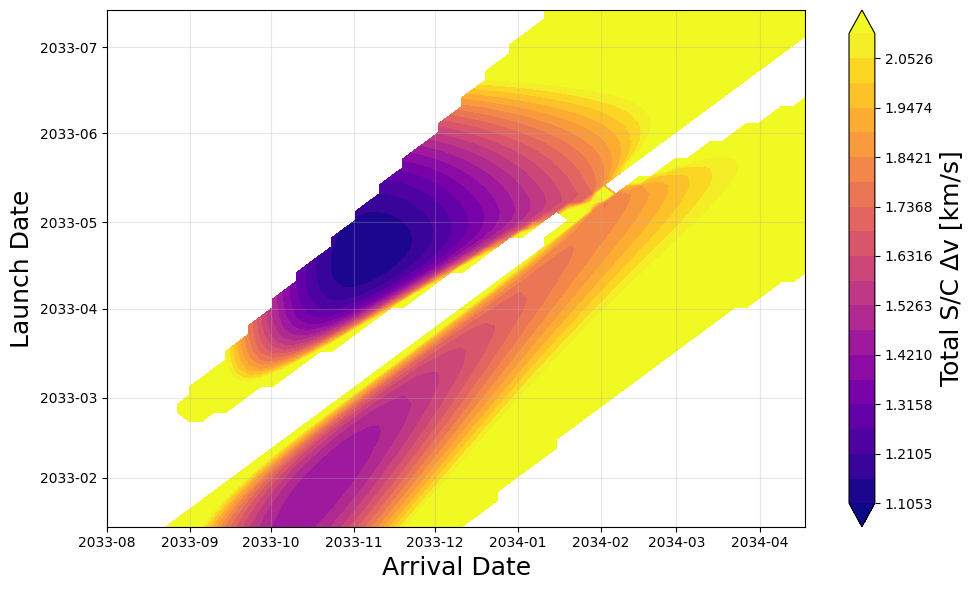

--- MISSION OPTIMUM FOUND ---
Minimum Total Δv: 1.105 km/s
1.907513632170924
0.10280706088468347


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy import units as u
from astropy.time import Time
from poliastro.bodies import Earth, Mars, Sun
from poliastro.twobody import Orbit
from poliastro.iod import lambert
from poliastro.util import norm


launch_dates = Time("2033-01-15") + np.linspace(0, 180, 60) * u.day 
arrival_dates = Time("2033-8-01") + np.linspace(0, 260, 60) * u.day

real_dv_matrix = np.full((len(launch_dates), len(arrival_dates)), np.nan)


mu_mars = Mars.k.to(u.km**3 / u.s**2).value
mu_sun = Sun.k.to(u.km**3 / u.s**2).value
r_periapsis = (3389.5 + 500) 

marscapture_dv = []
l1capture_dv = []

for i, ld in enumerate(launch_dates):
    for j, ad in enumerate(arrival_dates):
        tof = ad - ld
        if 180 < tof.value < 450:
            try:
                r_e, v_e = Orbit.from_body_ephem(Earth, ld).rv()
                r_m, v_m = Orbit.from_body_ephem(Mars, ad).rv()
                (v_dep, v_arr), = lambert(Sun.k, r_e, r_m, tof)
                
                d_sun_mars = norm(r_m).to(u.km).value
                
                r_l1 = d_sun_mars * (mu_mars / (3 * mu_sun))**(1/3)
                
                omega_mars = norm(v_m).to(u.km/u.s).value / d_sun_mars
                v_l1_lateral = omega_mars * r_l1
                
                v_inf = norm(v_arr - v_m).to(u.km/u.s).value
                v_per_arrival = np.sqrt(v_inf**2 + (2 * mu_mars / r_periapsis))
                
                a_capture = (r_periapsis + r_l1) / 2
                v_per_target = np.sqrt(mu_mars * ((2 / r_periapsis) - (1 / a_capture)))
                
                dv1_capture = v_per_arrival - v_per_target
                
                v_apo_arrival = v_per_target * (r_periapsis / r_l1)
                
                dv2_l1_insert = abs(v_l1_lateral - v_apo_arrival)

                
                
                total_dv = dv1_capture + dv2_l1_insert
                
                if 0.5 < total_dv < 3.0: 
                    marscapture_dv.append(dv1_capture)
                    l1capture_dv.append(dv2_l1_insert)
                    real_dv_matrix[i, j] = total_dv
            except:
                continue


plt.figure(figsize=(10, 6))
X, Y = np.meshgrid(arrival_dates.datetime, launch_dates.datetime)
vmin = np.nanmin(real_dv_matrix)
levels = np.linspace(vmin, vmin + 1.0, 20)

cp = plt.contourf(X, Y, real_dv_matrix, levels=levels, cmap="plasma", extend='both')
cbar = plt.colorbar(cp)
cbar.set_label("Total S/C Δv [km/s]", fontsize=18)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel("Arrival Date", fontsize=18)
plt.ylabel("Launch Date", fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if not np.all(np.isnan(real_dv_matrix)):
    idx = np.unravel_index(np.nanargmin(real_dv_matrix), real_dv_matrix.shape)
    print(f"--- MISSION OPTIMUM FOUND ---")
    print(f"Minimum Total Δv: {np.nanmin(real_dv_matrix):.3f} km/s")

print(np.mean(marscapture_dv))
print(np.mean(l1capture_dv))

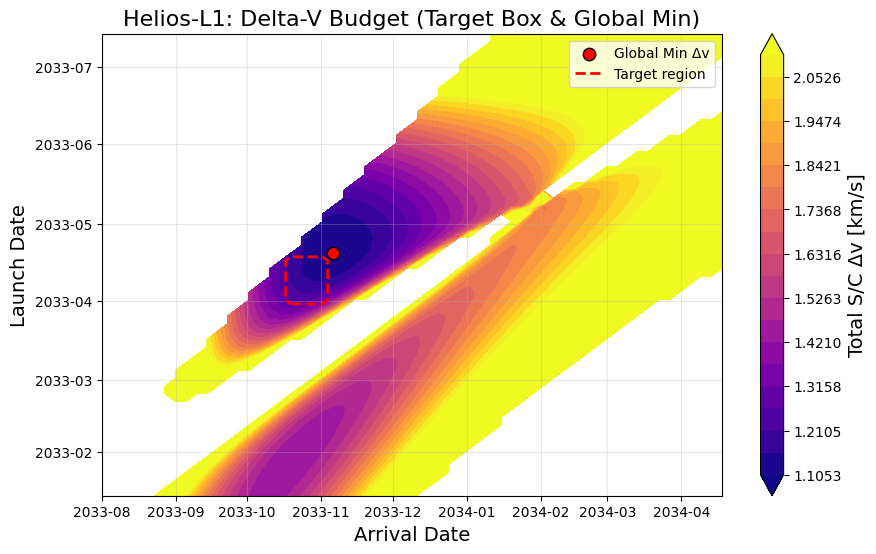

Minimum Total Δv: 1.105 km/s


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
from datetime import datetime
from astropy import units as u
from astropy.time import Time

launch_dt = launch_dates.datetime
arrival_dt = arrival_dates.datetime


min_idx = np.unravel_index(np.nanargmin(real_dv_matrix), real_dv_matrix.shape)
min_launch_dt = launch_dt[min_idx[0]]
min_arrival_dt = arrival_dt[min_idx[1]]

launch_grid, arrival_grid = np.meshgrid(launch_dt, arrival_dt, indexing='ij')

start_launch = datetime(2033, 4, 1)
end_launch   = datetime(2033, 4, 17)
start_arrival = datetime(2033, 10, 15)
end_arrival   = datetime(2033, 11, 2)

target_mask = (launch_grid >= start_launch) & \
              (launch_grid <= end_launch) & \
              (arrival_grid >= start_arrival) & \
              (arrival_grid < end_arrival)


plt.figure(figsize=(10, 6))
X, Y = np.meshgrid(arrival_dt, launch_dt)
vmin = np.nanmin(real_dv_matrix)
levels = np.linspace(vmin, vmin + 1.0, 20)


cp = plt.contourf(X, Y, real_dv_matrix, levels=levels, cmap="plasma", extend='both')
cbar = plt.colorbar(cp)
cbar.set_label("Total S/C Δv [km/s]", fontsize=14)


plt.contour(X, Y, target_mask.astype(int), levels=[0.5], colors='red', linewidths=2, linestyles='--')


min_marker = plt.scatter(min_arrival_dt, min_launch_dt, 
                         color='red', marker='o', s=80, edgecolor='black', label='Global Min Δv')


target_box_proxy = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label='Target region')


plt.legend(handles=[min_marker, target_box_proxy], loc='upper right')


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel("Arrival Date", fontsize=14)
plt.ylabel("Launch Date", fontsize=14)
plt.title("Helios-L1: Delta-V Budget (Target Box & Global Min)", fontsize=16)
plt.grid(alpha=0.3)


plt.savefig('helios_l1_porkchop.png', dpi=380, bbox_inches='tight')
plt.show()

print(f"Minimum Total Δv: {np.nanmin(real_dv_matrix):.3f} km/s")

In [4]:
print(min(marscapture_dv))
print(min(l1capture_dv))

0.9984449864772307
0.0950885448688154


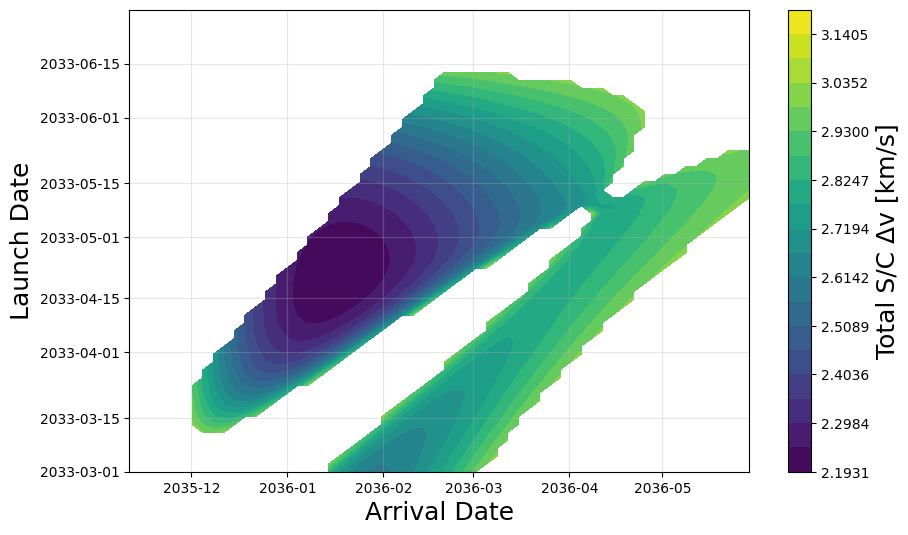

Minimum L5 Drift Δv: 2.193 km/s
1.2778129322302667
1.1999482362648186


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy import units as u
from astropy.time import Time
from poliastro.bodies import Earth, Mars, Sun
from poliastro.twobody import Orbit
from poliastro.iod import lambert
from poliastro.util import norm


launch_dates = Time("2033-03-01") + np.linspace(0, 120, 60) * u.day 
arrival_dates = Time("2033-09-01") + np.linspace(0, 200, 60) * u.day

l5_drift_matrix = np.full((len(launch_dates), len(arrival_dates)), np.nan)


mu_sun = Sun.k.to(u.km**3 / u.s**2).value
mu_mars = Mars.k.to(u.km**3 / u.s**2).value
r_per = 3389.5 + 500 

marsflyby_dv = []
l5capture_dv = []

for i, ld in enumerate(launch_dates):
    for j, ad in enumerate(arrival_dates):
        tof = ad - ld
        if 180 < tof.value < 450:
            try:
                r_e, v_e = Orbit.from_body_ephem(Earth, ld).rv()
                r_m, v_m = Orbit.from_body_ephem(Mars, ad).rv()
                (v_dep, v_arr), = lambert(Sun.k, r_e, r_m, tof)
                
                v_inf = norm(v_arr - v_m).to(u.km/u.s).value
                v_per_arrival = np.sqrt(v_inf**2 + (2 * mu_mars / r_per))
                
                r_sun_m = norm(r_m).to(u.km).value
                
                a_m = r_sun_m 
                a_drift = a_m * (7/6)**(2/3)
                
               
                v_drift_at_mars = np.sqrt(mu_sun * (2/r_sun_m - 1/a_drift))
                
                v_inf_required = abs(v_drift_at_mars - norm(v_m).to(u.km/u.s).value)
                
                v_per_target = np.sqrt(v_inf_required**2 + (2 * mu_mars / r_per))
                
                dv1_kick = abs(v_per_arrival - v_per_target)
                
                v_match = abs(np.sqrt(mu_sun/r_sun_m) - np.sqrt(mu_sun * (2/r_sun_m - 1/a_drift))) 
                
                total_dv = dv1_kick + v_match
                
                if total_dv < 3.0:
                    l5_drift_matrix[i, j] = total_dv
                if total_dv < 2.75:
                    marsflyby_dv.append(dv1_kick)
                    l5capture_dv.append(v_match)
            except:
                continue

arrival_dates = arrival_dates + 801 * u.day

plt.figure(figsize=(10, 6))
X, Y = np.meshgrid(arrival_dates.datetime, launch_dates.datetime)
vmin = np.nanmin(l5_drift_matrix)
levels = np.linspace(vmin, vmin + 1.0, 20)

cp = plt.contourf(X, Y, l5_drift_matrix, levels=levels, cmap="viridis")
cbar = plt.colorbar(cp) 
cbar.set_label("Total S/C Δv [km/s]", fontsize=18)
plt.xlabel("Arrival Date", fontsize=18)
plt.ylabel("Launch Date", fontsize=18)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.grid(alpha=0.3)
plt.show()

print(f"Minimum L5 Drift Δv: {np.nanmin(l5_drift_matrix):.3f} km/s")

print(np.mean(marsflyby_dv))
print(np.mean(l5capture_dv))

c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\wuert\miniforge3\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


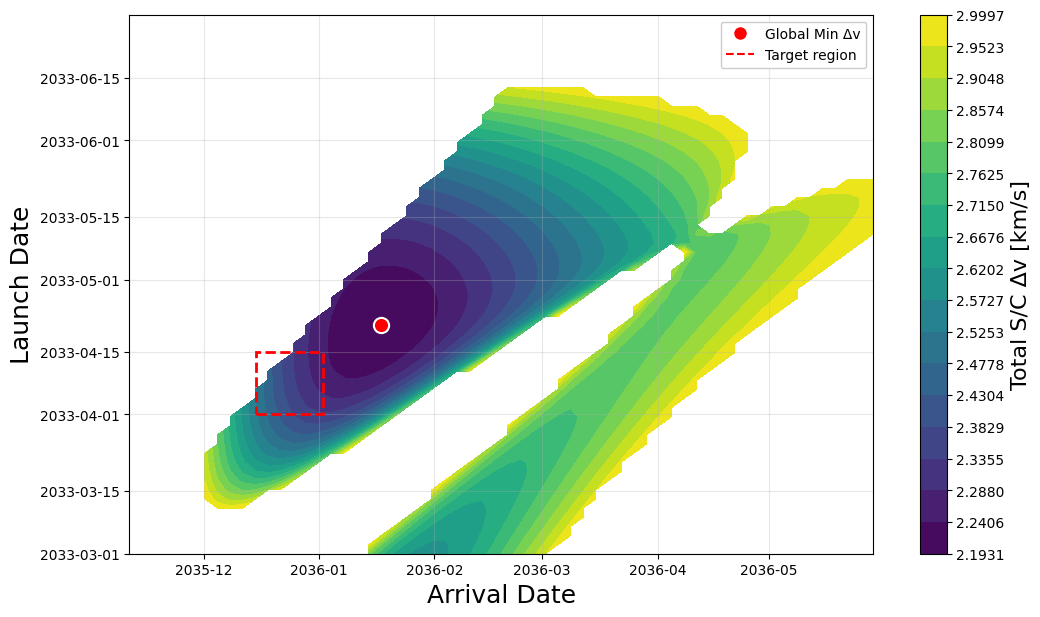

In [20]:
import matplotlib.patches as patches
import matplotlib.lines as mlines

i_min, j_min = np.unravel_index(np.nanargmin(l5_drift_matrix), l5_drift_matrix.shape)

fig, ax = plt.subplots(figsize=(12, 7))

X, Y = np.meshgrid(arrival_dt, launch_dt)

vmin = np.nanmin(l5_drift_matrix)
vmax = np.nanmax(l5_drift_matrix)
levels = np.linspace(vmin, vmax, 18) 

cp = ax.contourf(X, Y, l5_drift_matrix, levels=levels, cmap="viridis")

ax.scatter(arrival_dt[j_min], launch_dt[i_min], 
           color='red', marker='o', s=120, edgecolors='white', 
           linewidths=1.5, zorder=10)

rect_start_x = mdates.date2num(Time("2035-12-15").to_datetime())
rect_start_y = mdates.date2num(Time("2033-04-01").to_datetime())

rect = patches.Rectangle((rect_start_x, rect_start_y), 
                         18, 14, 
                         linewidth=2, edgecolor='red', facecolor='none', 
                         linestyle='--', zorder=11)
ax.add_patch(rect)

cbar = fig.colorbar(cp)
cbar.set_label("Total S/C Δv [km/s]", fontsize=16)
cbar.set_ticks(levels)

min_leg = mlines.Line2D([], [], color='red', marker='o', linestyle='None', 
                         markersize=10, markeredgecolor='white', label='Global Min Δv')
target_leg = mlines.Line2D([], [], color='red', linestyle='--', label='Target region')
ax.legend(handles=[min_leg, target_leg], loc='upper right', framealpha=1)

ax.set_xlabel("Arrival Date", fontsize=18)
ax.set_ylabel("Launch Date", fontsize=18)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True, alpha=0.3)

plt.savefig('L5_Porkchop_Discrete.jpg', dpi=380, bbox_inches='tight')
plt.show()

In [60]:
# print(marsflyby_dv)
# print(l5capture_dv)
print(min(marsflyby_dv))
print(min(l5capture_dv))

0.9858438219738623
1.1600352796875129
